# Data Visualization and Dashboards in Python

Numbers in a table are hard to read. Pictures are easy. This notebook teaches you how to turn data into clear, honest, professional charts — and how to combine several charts into a **dashboard** (a small collection of charts that together answer one question).

We will use three real datasets that come bundled with the libraries, so nothing needs to be downloaded by hand.

**What you will learn:**

- Why we visualize data at all (with a famous demo: Anscombe's quartet)
- How to choose the right chart for the right question
- Matplotlib fundamentals: figures, axes, titles, labels, legends
- A gallery of the core chart types and when to use each one
- Seaborn: statistical charts with very little code
- Design principles that make your charts look professional
- Interactive charts with Plotly (hover, zoom, animation)
- How to build a static dashboard and an interactive dashboard
- How to export a dashboard as a single HTML file anyone can open

## How to run this notebook

- **Locally (Jupyter):** open this file in Jupyter Notebook, JupyterLab, or VS Code and run the cells from top to bottom.
- **Google Colab:** upload the notebook (or open it straight from GitHub) and run the cells in order.

The **setup cell** below installs any missing packages automatically, so you do not need to prepare anything. No accounts, no API keys.

One note about the interactive Plotly charts: they only appear when you **run** the notebook. GitHub's file preview shows static images only, so if a chart looks empty on GitHub, just run the notebook yourself.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("matplotlib"); ensure("seaborn"); ensure("plotly")

Now we import the libraries and give each one a short nickname (this is the standard convention you will see everywhere):

- `pandas` (nickname `pd`) — tables of data
- `matplotlib.pyplot` (nickname `plt`) — the classic charting library
- `seaborn` (nickname `sns`) — statistical charts built on top of matplotlib
- `plotly.express` (nickname `px`) — interactive charts

We also create an `outputs/` folder next to the notebook. Every file we save (images, HTML dashboards) goes in there.

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Make Plotly figures render both in local Jupyter and on Google Colab.
import plotly.io as pio
import sys
if "google.colab" not in sys.modules:
    pio.renderers.default = "notebook_connected"

os.makedirs("outputs", exist_ok=True)
print("Libraries loaded. Files we create will be saved in the 'outputs/' folder.")

Libraries loaded. Files we create will be saved in the 'outputs/' folder.


## 1. Why visualize? Anscombe's quartet

In 1973 the statistician Francis Anscombe built four tiny datasets with a trick: they all have **almost identical summary statistics** (same means, same standard deviations, same correlation), yet they look completely different when you plot them.

- **Summary statistics** = single numbers that describe a whole column, like the mean (average).
- **Correlation** = a number between -1 and 1 that says how strongly two columns move together.

The lesson: statistics can hide the shape of your data. A plot reveals it. Let's see it with our own eyes.

First we load the quartet (seaborn ships it as a practice dataset) and compute the summary statistics per group.

In [3]:
# Load Anscombe's quartet: 4 small datasets labelled I, II, III, IV.
anscombe = sns.load_dataset("anscombe")
anscombe.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


All four datasets are stacked in one table; the `dataset` column says which one each row belongs to. Now compute the mean and standard deviation of x and y, plus the x-y correlation, separately per dataset. If Anscombe was right, the four rows should come out almost identical.

In [4]:
# Summary statistics per dataset: mean and standard deviation of x and y.
summary_stats = anscombe.groupby("dataset").agg(
    x_mean=("x", "mean"),
    x_std=("x", "std"),
    y_mean=("y", "mean"),
    y_std=("y", "std"),
)

# Correlation between x and y, computed separately for each of the 4 datasets.
correlations = {name: group["x"].corr(group["y"]) for name, group in anscombe.groupby("dataset")}
summary_stats["xy_correlation"] = pd.Series(correlations)

summary_stats.round(2)

,x_mean,x_std,y_mean,y_std,xy_correlation
dataset,,,,,
I,9.0,3.32,7.5,2.03,0.82
II,9.0,3.32,7.5,2.03,0.82
III,9.0,3.32,7.5,2.03,0.82
IV,9.0,3.32,7.5,2.03,0.82


The four rows are almost identical. Now let's plot the four datasets side by side. `sns.lmplot` draws a scatter plot plus a fitted straight line, and `col="dataset"` makes one panel per dataset.

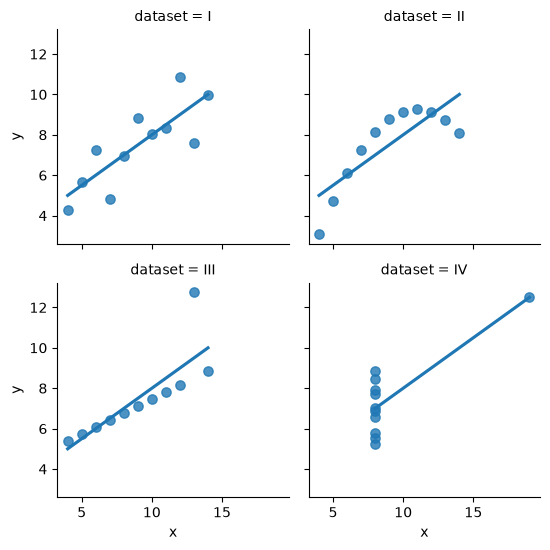

In [5]:
sns.lmplot(
    data=anscombe, x="x", y="y",
    col="dataset", col_wrap=2,        # 4 panels, 2 per row
    ci=None, height=2.8,              # no confidence band, small panels
    scatter_kws={"s": 45},
)
plt.show()

Same statistics, four totally different stories:

- **I** is a normal cloud of points.
- **II** is a curve — a straight line is the wrong model.
- **III** is a perfect line with one outlier pulling the fit.
- **IV** is a vertical stack where a single point creates the whole "trend".

**Takeaway:** always plot your data before you trust any number about it.

## 2. Choosing the right chart

Every chart answers one kind of question. Match the question to the chart and you are 80% done. Keep this table close:

| Your question | Chart to use |
|---|---|
| Compare categories ("Which country is biggest?") | Bar chart |
| See a distribution ("How are values spread out?") | Histogram or box plot |
| See a relationship ("Do x and y move together?") | Scatter plot |
| See a trend over time ("Is it going up or down?") | Line chart |
| Show parts of a whole ("What is each share?") | Stacked bar chart |

- **Distribution** = the shape of where values fall: are most values small, large, spread out, clumped?

### The pie chart rule

You may notice pie charts are missing from the table. Here is a design rule you should adopt today: **never use a pie chart with more than 3 categories.** Humans are bad at comparing angles and slice areas, but very good at comparing bar lengths. Let's prove it with a side-by-side demo using world population by continent.

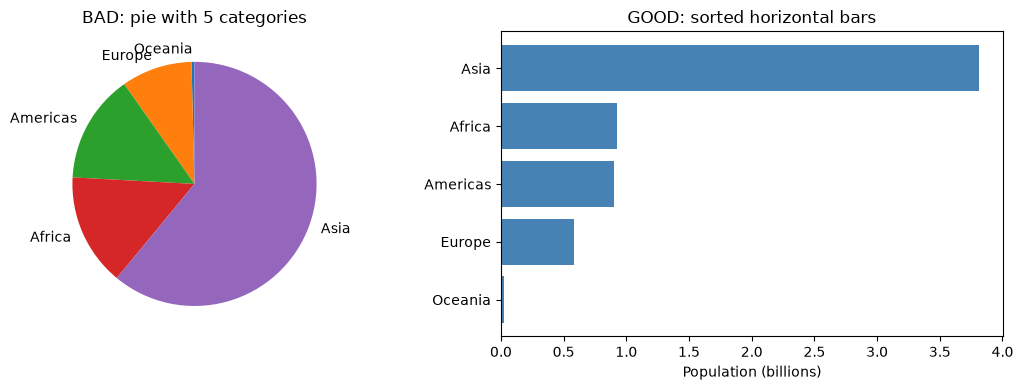

In [6]:
# World population by continent in 2007, from the Gapminder dataset (bundled with Plotly).
gapminder = px.data.gapminder()
pop_2007 = (
    gapminder.loc[gapminder["year"] == 2007]
    .groupby("continent")["pop"].sum()
    .sort_values()
)

fig, (ax_bad, ax_good) = plt.subplots(1, 2, figsize=(11, 4))

# BAD: a pie chart with 5 categories. Which is bigger, Europe or Africa? Hard to tell.
ax_bad.pie(pop_2007, labels=pop_2007.index, startangle=90)
ax_bad.set_title("BAD: pie with 5 categories")

# GOOD: a sorted horizontal bar chart. The comparison is instant.
ax_good.barh(pop_2007.index, pop_2007 / 1e9, color="steelblue")
ax_good.set_xlabel("Population (billions)")
ax_good.set_title("GOOD: sorted horizontal bars")

plt.tight_layout()
plt.show()

On the pie you have to squint to rank Europe vs Africa vs the Americas. On the bar chart the ranking is instant and you can even read approximate values. Sorted horizontal bars beat pies almost every time — we will use them for the rest of the course.

## 3. Matplotlib fundamentals

Matplotlib is the foundation: almost every Python charting tool (including seaborn) is built on it. Two words you must know:

- **Figure** = the whole canvas (the piece of paper).
- **Axes** = one chart drawn on that canvas (the plot area with its x-axis and y-axis). One figure can hold many axes.

The standard pattern is always the same three steps:

```python
fig, ax = plt.subplots()   # 1. create a figure with one axes
ax.plot(x, y)              # 2. draw on the axes
plt.show()                 # 3. display it
```

Let's meet our main dataset properly first. **Gapminder** tracks countries over time: life expectancy (`lifeExp`, average years a newborn is expected to live), income per person (`gdpPercap`), and population (`pop`), every 5 years from 1952 to 2007.

In [7]:
# gapminder was already loaded in section 2; now look at its size and first rows
print(gapminder.shape)   # (rows, columns)
gapminder.head()

(1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


### One line chart, done properly

A **line chart** shows a trend over time. We will plot life expectancy in the Netherlands, and add the four labels every real chart needs: a title, an x-axis label, a y-axis label, and (when there are several lines) a legend.

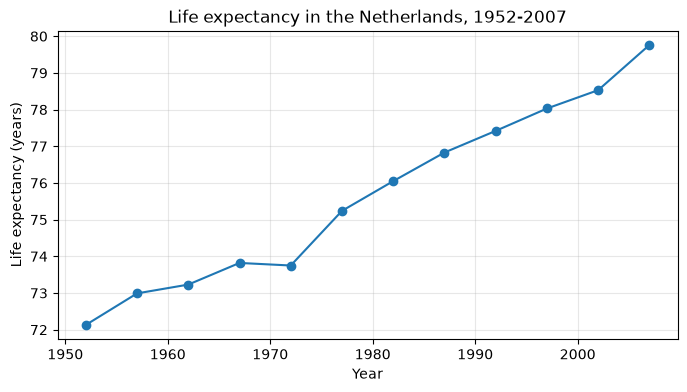

In [8]:
netherlands = gapminder.loc[gapminder["country"] == "Netherlands"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(netherlands["year"], netherlands["lifeExp"], marker="o")

ax.set_title("Life expectancy in the Netherlands, 1952-2007")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
ax.grid(True, alpha=0.3)   # light gridlines help reading values

plt.show()

### Several lines with a loop

To compare countries we draw one line per country. A simple `for` loop does it: each `ax.plot` call adds one line, and `label=` gives it a name for the **legend** (the small box that says which line is which).

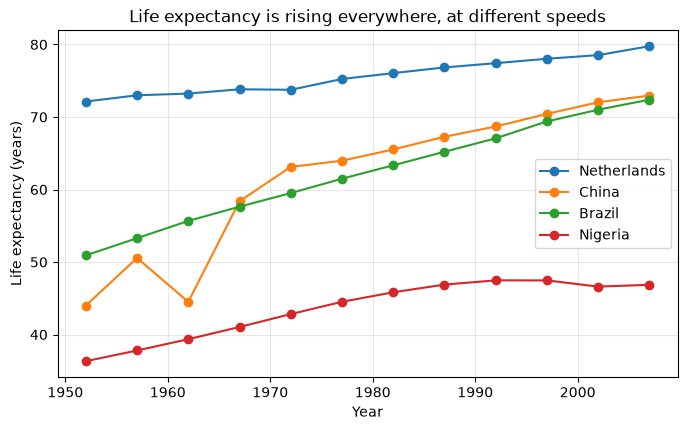

In [9]:
countries = ["Netherlands", "China", "Brazil", "Nigeria"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for country in countries:
    subset = gapminder.loc[gapminder["country"] == country]
    ax.plot(subset["year"], subset["lifeExp"], marker="o", label=country)

ax.set_title("Life expectancy is rising everywhere, at different speeds")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### Saving a figure to a file

`fig.savefig` writes the figure to disk. `dpi=150` controls the resolution (dots per inch) and `bbox_inches="tight"` trims empty borders. We save into the `outputs/` folder we created in the setup.

In [10]:
fig.savefig("outputs/life_expectancy_lines.png", dpi=150, bbox_inches="tight")
print("Saved:", os.path.abspath("outputs/life_expectancy_lines.png"))

Saved: /Users/maglionejuanmartin/code/fontys-tech-exercies/M1 - Descriptive analytics/outputs/life_expectancy_lines.png


## 4. Core chart gallery (matplotlib)

Four workhorse charts, each with a one-line "when to use". For all of them we use the 2007 snapshot of Gapminder.

In [11]:
g2007 = gapminder.loc[gapminder["year"] == 2007]
print(f"{len(g2007)} countries in the 2007 snapshot")

142 countries in the 2007 snapshot


### 4.1 Bar chart — *use it to compare categories*

Average life expectancy per continent. Vertical bars first; then the same data as **sorted horizontal bars**, which are easier to read when labels are long — notice how sorting instantly shows the ranking.

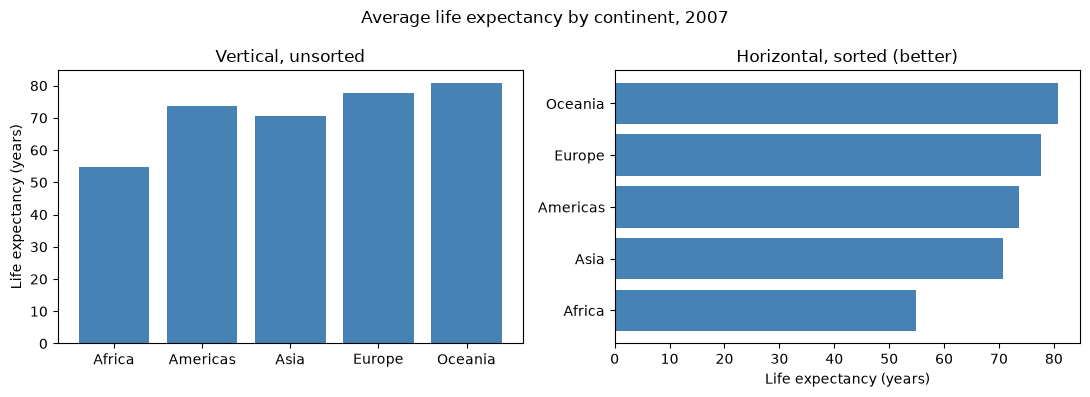

In [12]:
life_by_continent = g2007.groupby("continent")["lifeExp"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Vertical bars, alphabetical order (the default - not ideal)
ax1.bar(life_by_continent.index, life_by_continent, color="steelblue")
ax1.set_title("Vertical, unsorted")
ax1.set_ylabel("Life expectancy (years)")

# Horizontal bars, sorted so the ranking is obvious
sorted_life = life_by_continent.sort_values()
ax2.barh(sorted_life.index, sorted_life, color="steelblue")
ax2.set_title("Horizontal, sorted (better)")
ax2.set_xlabel("Life expectancy (years)")

fig.suptitle("Average life expectancy by continent, 2007")
plt.tight_layout()
plt.show()

### 4.2 Histogram — *use it to see the distribution of one numeric column*

A **histogram** chops a numeric column into intervals ("bins") and counts how many values fall in each. The number of bins changes the picture, so always try a few: too few bins hides detail, too many turns into noise.

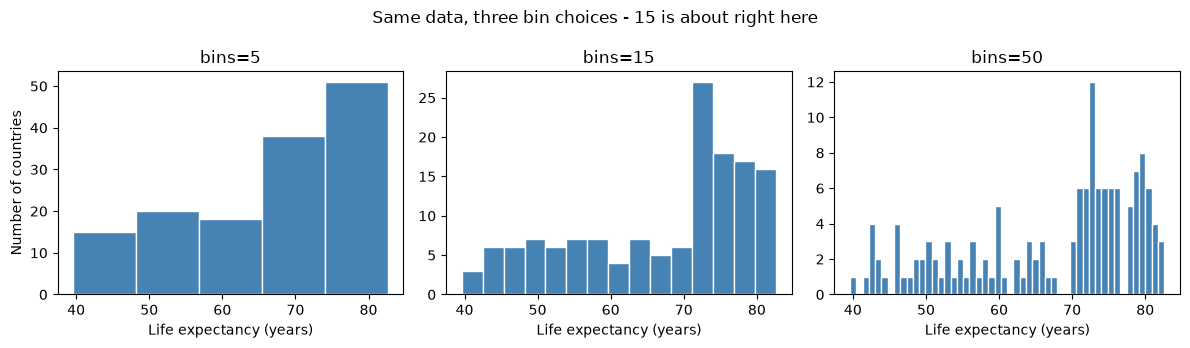

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)

for ax, bins in zip(axes, [5, 15, 50]):
    ax.hist(g2007["lifeExp"], bins=bins, color="steelblue", edgecolor="white")
    ax.set_title(f"bins={bins}")
    ax.set_xlabel("Life expectancy (years)")

axes[0].set_ylabel("Number of countries")
fig.suptitle("Same data, three bin choices - 15 is about right here")
plt.tight_layout()
plt.show()

With ~15 bins you can see the real story: life expectancy in 2007 has **two humps** — a large group of countries around 70-80 years and a smaller group around 45-60 years. Five bins hid that completely.

### 4.3 Scatter plot — *use it to see the relationship between two numeric columns*

Each point is one country. We plot income per person (x) against life expectancy (y). Because incomes range from a few hundred to tens of thousands of dollars, we use a **logarithmic x-axis** (each step multiplies by 10 instead of adding a fixed amount) so the poorer countries do not get squashed against the left edge.

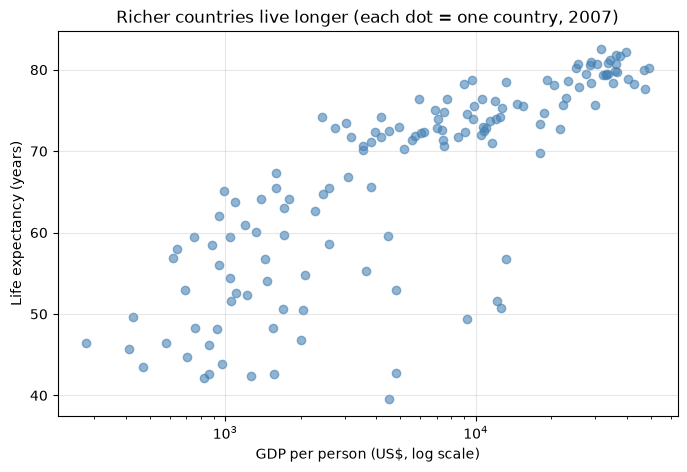

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(g2007["gdpPercap"], g2007["lifeExp"], alpha=0.6, color="steelblue")

ax.set_xscale("log")   # logarithmic axis
ax.set_title("Richer countries live longer (each dot = one country, 2007)")
ax.set_xlabel("GDP per person (US$, log scale)")
ax.set_ylabel("Life expectancy (years)")
ax.grid(True, alpha=0.3)

plt.show()

### 4.4 Box plot — *use it to compare distributions across categories*

A **box plot** summarizes a distribution in one glyph: the box covers the middle 50% of values, the line inside is the **median** (the middle value), the whiskers show the typical range, and dots beyond them are **outliers** (unusually extreme values).

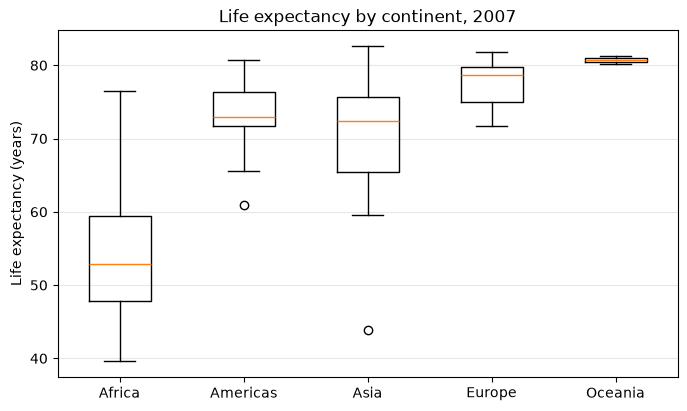

In [15]:
continents = sorted(g2007["continent"].unique())
data_per_continent = [g2007.loc[g2007["continent"] == c, "lifeExp"] for c in continents]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(data_per_continent, tick_labels=continents)

ax.set_title("Life expectancy by continent, 2007")
ax.set_ylabel("Life expectancy (years)")
ax.grid(True, axis="y", alpha=0.3)

plt.show()

Read it like this: Africa's box is low and tall (low life expectancy, huge variation between countries), while Europe's box is high and short (high life expectancy, countries quite similar).

**Gallery recap:**

| Chart | One-line "when to use" |
|---|---|
| Bar / barh | Compare a number across categories |
| Histogram | See the shape of one numeric column |
| Scatter | See how two numeric columns relate |
| Box plot | Compare distributions across categories |

## 5. Seaborn: statistical plots made easy

Seaborn is a layer on top of matplotlib. You give it a DataFrame and column names; it handles grouping, colors and legends for you. `sns.set_theme()` switches on its clean default style for all plots that follow.

We will use two friendly practice datasets:

- **tips** — restaurant bills: total bill, tip, day, time, party size.
- **penguins** — body measurements of 344 penguins from 3 species.

In [16]:
sns.set_theme(style="whitegrid")   # clean look for everything from here on

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()   # drop rows with missing measurements

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Countplot — how many rows per category

`countplot` counts rows for you (no groupby needed). Question: which day has the most restaurant visits in our data?

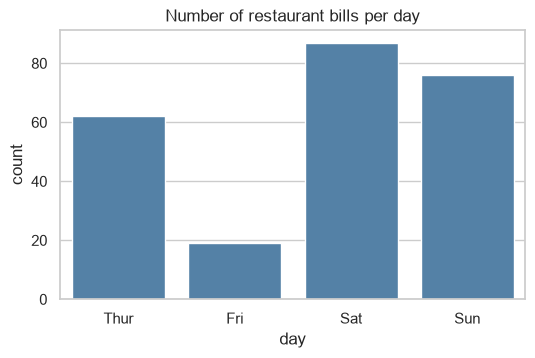

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(data=tips, x="day", color="steelblue", ax=ax)
ax.set_title("Number of restaurant bills per day")
plt.show()

### Barplot — the average per category

`sns.barplot` shows the **mean** (average) of a numeric column per category. By default it adds error bars (small lines showing uncertainty); we switch them off with `errorbar=None` to keep the chart simple.

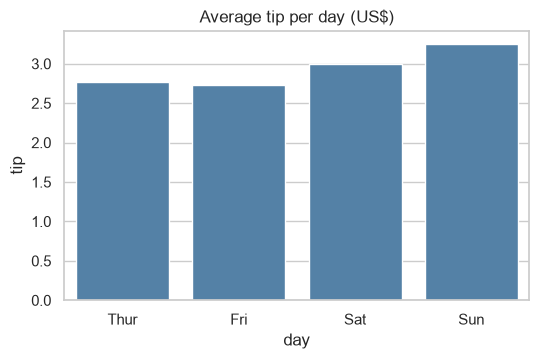

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=tips, x="day", y="tip", errorbar=None, color="steelblue", ax=ax)
ax.set_title("Average tip per day (US$)")
plt.show()

### Boxplot and violinplot side by side

A **violin plot** is a box plot's cousin: instead of a box it draws the full shape of the distribution (wider = more values there). Same question, two views: how do total bills differ per day?

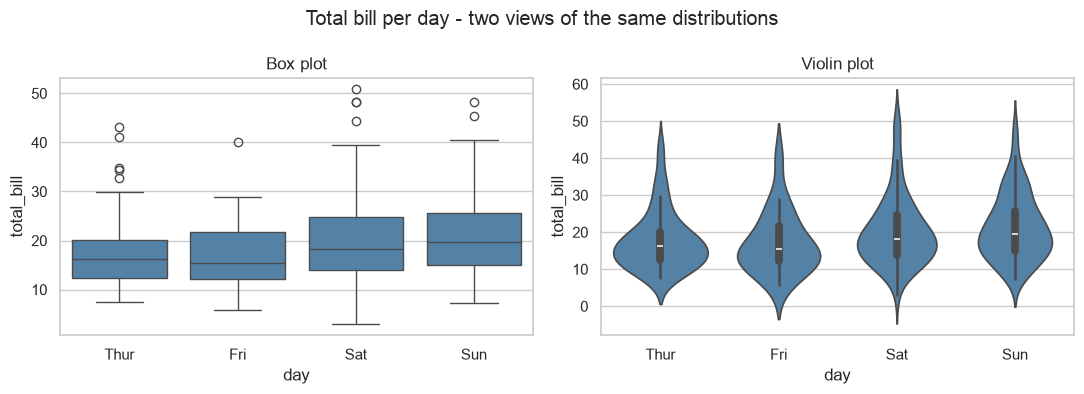

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=tips, x="day", y="total_bill", color="steelblue", ax=ax1)
ax1.set_title("Box plot")

sns.violinplot(data=tips, x="day", y="total_bill", color="steelblue", ax=ax2)
ax2.set_title("Violin plot")

fig.suptitle("Total bill per day - two views of the same distributions")
plt.tight_layout()
plt.show()

### Scatterplot with hue and size

Seaborn can encode extra columns into a scatter plot: `hue=` maps a column to **color**, `size=` maps a column to **dot size**. Here: bigger bills get bigger tips, dinner (orange) dominates the high end, and larger parties (bigger dots) sit to the right.

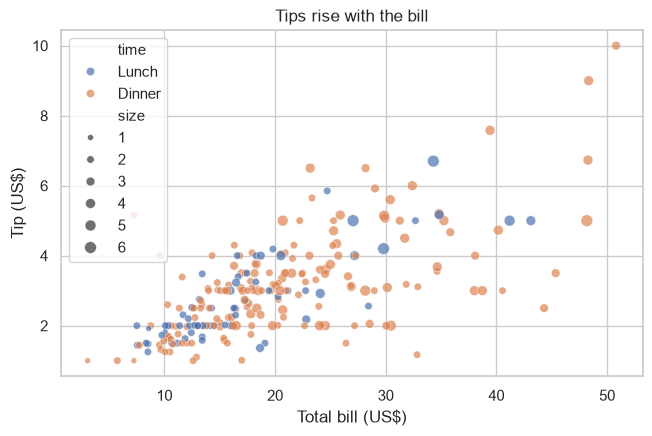

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="time", size="size", alpha=0.7, ax=ax)
ax.set_title("Tips rise with the bill")
ax.set_xlabel("Total bill (US$)")
ax.set_ylabel("Tip (US$)")
plt.show()

### Histplot with hue — compare distributions in one panel

One histogram per penguin species, overlaid with transparency. You can instantly see that Gentoo penguins have clearly longer flippers.

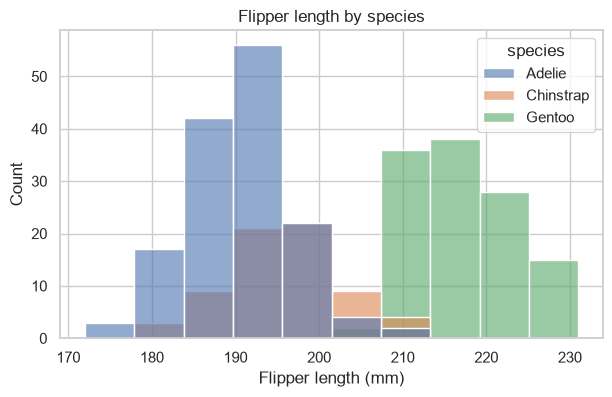

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", alpha=0.6, ax=ax)
ax.set_title("Flipper length by species")
ax.set_xlabel("Flipper length (mm)")
plt.show()

### Heatmap of a correlation matrix

A **correlation matrix** holds the correlation between every pair of numeric columns. A **heatmap** paints those numbers as colors, so patterns jump out. `annot=True` prints the numbers in the cells.

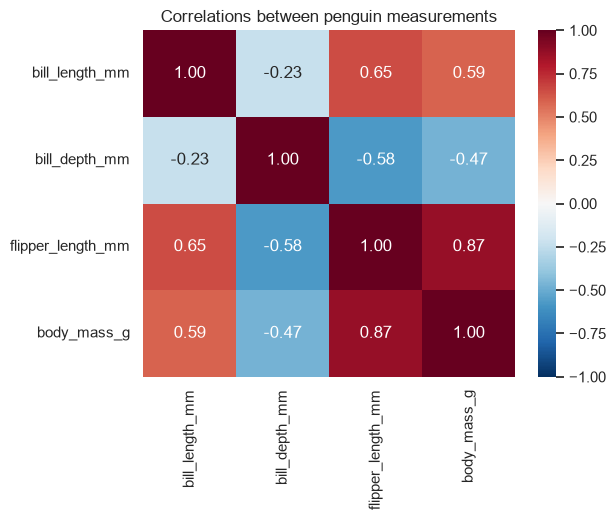

In [22]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlations between penguin measurements")
plt.show()

Read it: flipper length and body mass correlate strongly (+0.87) — bigger penguins have bigger flippers. Bill depth correlates *negatively* with flipper length; that is the species mix at work.

### Pairplot — every scatter at once

`pairplot` draws a scatter plot for every pair of columns (and a distribution on the diagonal). It is a great **first look** at a new dataset. Keep it small — a few columns only — or it gets slow and unreadable.

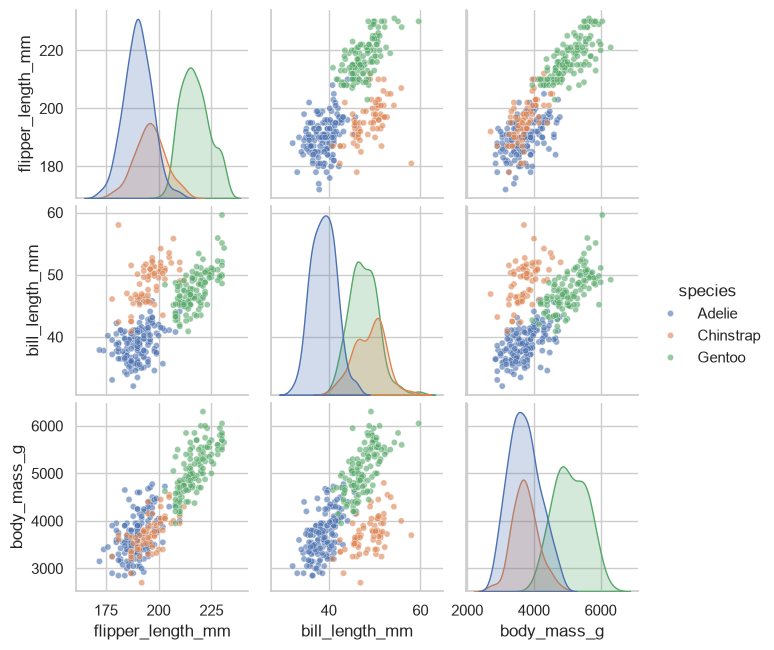

In [23]:
sns.pairplot(
    penguins[["flipper_length_mm", "bill_length_mm", "body_mass_g", "species"]],
    hue="species", height=2.2, plot_kws={"alpha": 0.6, "s": 20},
)
plt.show()

## 6. Design principles: from "default" to "professional"

Correct charts are not automatically good charts. Five habits separate student charts from professional ones:

1. **Declutter.** Remove everything that carries no information: heavy borders (called **spines**), dense gridlines, redundant legends.
2. **Sort your bars.** Alphabetical order answers no question; sorted order shows the ranking.
3. **Label directly.** Put the value at the end of the bar instead of forcing readers to trace gridlines.
4. **One message per chart.** If a chart says three things, split it into three charts.
5. **Color with intent.** Grey for context, one color for the thing you are talking about.

And the bonus habit that ties them together: **the title states the takeaway.** "Life expectancy by continent" describes the axes; "Africa trails the rest of the world by 15+ years" tells the reader what to see.

Let's apply all five to the same chart, before vs after.

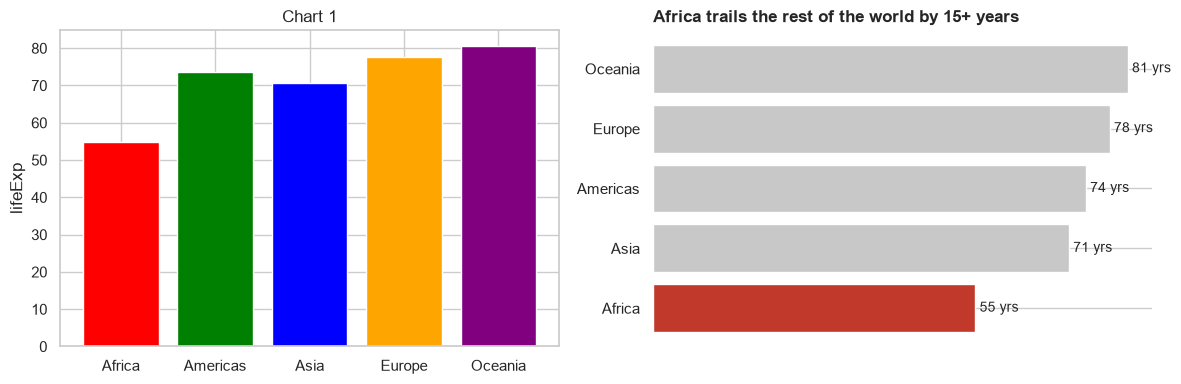

In [24]:
life_2007 = g2007.groupby("continent")["lifeExp"].mean().sort_values()

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 4))

# BEFORE: matplotlib defaults, unsorted, vague title, rainbow colors.
before = g2007.groupby("continent")["lifeExp"].mean()   # alphabetical order
ax_before.bar(before.index, before, color=["red", "green", "blue", "orange", "purple"])
ax_before.set_title("Chart 1")
ax_before.set_ylabel("lifeExp")

# AFTER: sorted, decluttered, direct labels, one highlight color, takeaway title.
highlight = "#c0392b"                       # red for the story (Africa)
colors = [highlight if c == "Africa" else "#c8c8c8" for c in life_2007.index]

ax_after.barh(life_2007.index, life_2007, color=colors)
for spine in ["top", "right", "left", "bottom"]:        # 1. declutter: no box
    ax_after.spines[spine].set_visible(False)
ax_after.set_xticks([])                                  # 3. direct labels replace the axis
for i, value in enumerate(life_2007):
    ax_after.text(value + 0.7, i, f"{value:.0f} yrs", va="center", fontsize=10)
ax_after.set_title("Africa trails the rest of the world by 15+ years",
                   loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Same data, same chart type — but the right-hand version needs zero effort to read and makes its point in one second. That is the goal every time.

A note for later in your studies: these habits (sorting, decluttering, highlight color, takeaway titles) apply identically in Power BI, Tableau, Excel and slides. The tool changes; the principles do not.

## 7. Interactive charts with Plotly Express

So far our charts were static images. **Plotly Express** (`px`) makes charts you can play with in the browser:

- **Hover** — move the mouse over a point to see its exact values.
- **Zoom** — drag a rectangle to zoom into that region (double-click to reset).
- **Pan** — drag the chart around after zooming.

The code style feels like seaborn: pass a DataFrame and column names. Let's redo our Gapminder charts, interactive this time.

### Interactive line chart

In [25]:
subset = gapminder.loc[gapminder["country"].isin(["Netherlands", "China", "Brazil", "Nigeria"])]

fig = px.line(
    subset, x="year", y="lifeExp", color="country", markers=True,
    title="Life expectancy 1952-2007 (hover a point for exact values)",
    labels={"lifeExp": "Life expectancy (years)", "year": "Year"},
)
fig.show()

### Interactive scatter — the classic Gapminder view

`hover_name="country"` puts the country name in bold at the top of the tooltip. Dot size = population, color = continent, log x-axis for income. Try hovering the biggest dots.

In [26]:
fig = px.scatter(
    g2007, x="gdpPercap", y="lifeExp",
    color="continent", size="pop", size_max=55,
    hover_name="country", log_x=True,
    title="Wealth vs health, 2007 (dot size = population)",
    labels={"gdpPercap": "GDP per person (US$, log scale)", "lifeExp": "Life expectancy (years)"},
)
fig.show()

### The famous animated bubble chart

Add `animation_frame="year"` and Plotly builds a play button that steps through the years — this is the chart Hans Rosling made famous in his TED talks. Press play and watch the world get richer and healthier over 55 years. (`animation_group="country"` keeps each bubble attached to its country between frames, and `range_x`/`range_y` freeze the axes so only the data moves.)

In [27]:
fig = px.scatter(
    gapminder, x="gdpPercap", y="lifeExp",
    color="continent", size="pop", size_max=55,
    hover_name="country", log_x=True,
    animation_frame="year", animation_group="country",
    range_x=[200, 200000], range_y=[25, 90],
    title="55 years of world development - press play",
    labels={"gdpPercap": "GDP per person (US$, log scale)", "lifeExp": "Life expectancy (years)"},
)
fig.show()

### Interactive box plot and bar chart

Two more one-liners. Hover a box to read its median and quartiles exactly — something a static box plot cannot do.

In [28]:
fig = px.box(
    g2007, x="continent", y="lifeExp",
    title="Life expectancy by continent, 2007 (hover a box for the exact numbers)",
    labels={"lifeExp": "Life expectancy (years)", "continent": ""},
)
fig.show()

And the ranking bar chart: sort the 2007 snapshot by population and keep the last 10 rows — the ten most populous countries.

In [29]:
top10_pop = g2007.sort_values("pop").tail(10)

fig = px.bar(
    top10_pop, x="pop", y="country", orientation="h",   # orientation="h" = horizontal bars
    title="The 10 most populous countries, 2007",
    labels={"pop": "Population", "country": ""},
)
fig.show()

## 8. Dashboards

### 8.1 What a dashboard is

A **dashboard** is a small set of charts shown together that jointly answer one question. Not "all the charts I made" — a curated set, arranged for a specific reader. Three rules:

- **One question per dashboard.** Ours will be: *"How was the world doing in 2007?"*
- **KPI first.** A **KPI** (key performance indicator) is the single headline number your reader cares about most. Put it top-left, big — that is where eyes land first.
- **Think about your audience.** A manager wants 4 charts and a conclusion; an analyst may want 20 charts and filters. Design for the reader, not for yourself.

A classic 2x2 layout: KPI top-left, then three charts that explain the number: a comparison, a relationship, and a ranking.

### 8.2 A static dashboard with matplotlib

`plt.subplots(2, 2)` gives us a 2x2 grid of axes — four mini-charts on one figure. For the KPI panel we simply turn the axis off and write big text on it. `fig.suptitle` puts one shared title over everything.

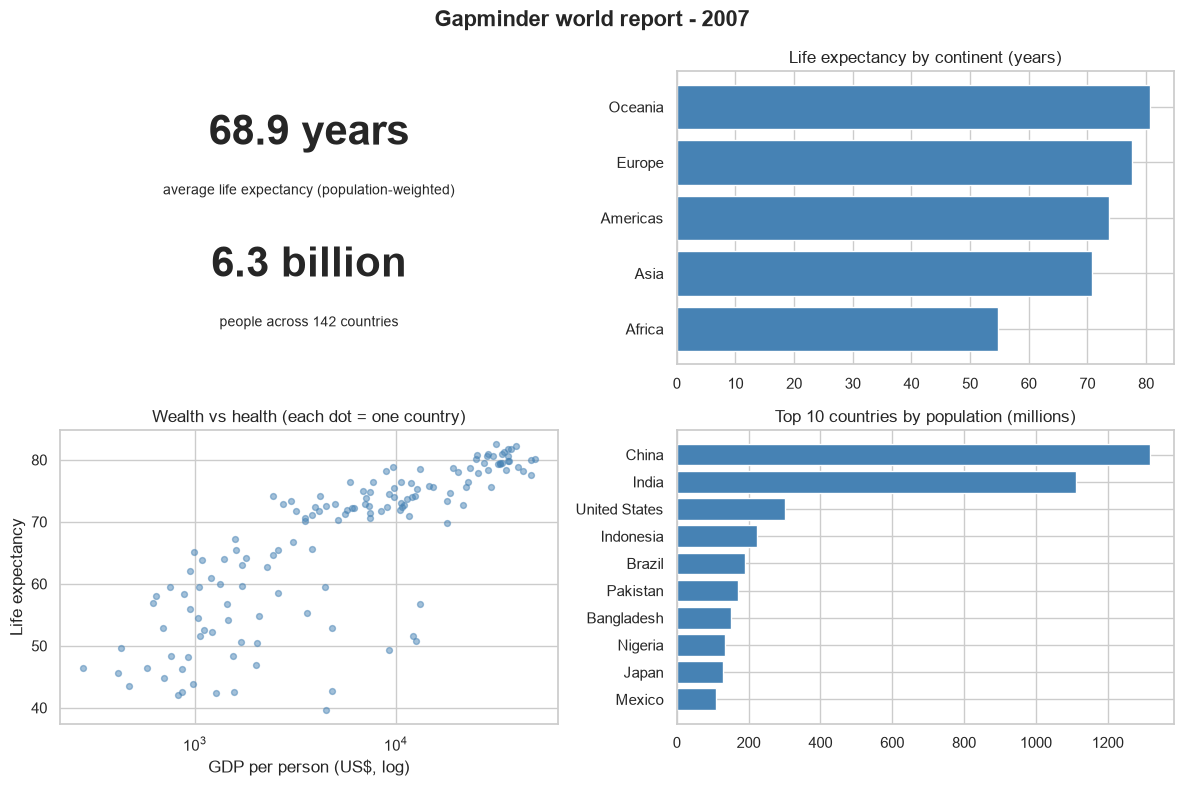

In [30]:
# The numbers for our "Gapminder 2007 world report"
world_life = (g2007["lifeExp"] * g2007["pop"]).sum() / g2007["pop"].sum()   # population-weighted
world_pop_b = g2007["pop"].sum() / 1e9
life_by_cont = g2007.groupby("continent")["lifeExp"].mean().sort_values()
top10_pop = g2007.sort_values("pop").tail(10)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Panel 1 (top-left): the KPIs, as big text on an empty axis
ax = axes[0, 0]
ax.axis("off")
ax.text(0.5, 0.75, f"{world_life:.1f} years", ha="center", fontsize=30, fontweight="bold")
ax.text(0.5, 0.58, "average life expectancy (population-weighted)", ha="center", fontsize=10)
ax.text(0.5, 0.30, f"{world_pop_b:.1f} billion", ha="center", fontsize=30, fontweight="bold")
ax.text(0.5, 0.13, f"people across {g2007['country'].nunique()} countries", ha="center", fontsize=10)

# Panel 2 (top-right): comparison - life expectancy by continent
ax = axes[0, 1]
ax.barh(life_by_cont.index, life_by_cont, color="steelblue")
ax.set_title("Life expectancy by continent (years)")

# Panel 3 (bottom-left): relationship - wealth vs health
ax = axes[1, 0]
ax.scatter(g2007["gdpPercap"], g2007["lifeExp"], alpha=0.5, color="steelblue", s=18)
ax.set_xscale("log")
ax.set_title("Wealth vs health (each dot = one country)")
ax.set_xlabel("GDP per person (US$, log)")
ax.set_ylabel("Life expectancy")

# Panel 4 (bottom-right): ranking - the population giants
ax = axes[1, 1]
ax.barh(top10_pop["country"], top10_pop["pop"] / 1e6, color="steelblue")
ax.set_title("Top 10 countries by population (millions)")

fig.suptitle("Gapminder world report - 2007", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig("outputs/world_report_2007.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 An interactive dashboard with Plotly

Plotly can do the same grid, but interactive. `make_subplots` creates the grid; `fig.add_trace(..., row=, col=)` places each chart. Two new ideas:

- A **trace** is Plotly's word for one chart layer (one set of bars, one cloud of dots).
- The KPI panel uses a special trace type, `go.Indicator`, which displays a big number — with a built-in **delta**, the change versus a reference value (we compare 2007 with 1952).

This needs the lower-level `plotly.graph_objects` (nickname `go`) instead of the express shortcut — a bit more code, full control in return.

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Reference for the KPI delta: world life expectancy in 1952
g1952 = gapminder.loc[gapminder["year"] == 1952]
world_life_1952 = (g1952["lifeExp"] * g1952["pop"]).sum() / g1952["pop"].sum()

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "indicator"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(None, "Life expectancy by continent",
                    "Wealth vs health", "Top 10 by population (millions)"),
)

# Panel 1: KPI with delta vs 1952
fig.add_trace(go.Indicator(
    mode="number+delta",
    value=world_life,
    number={"suffix": " yrs", "valueformat": ".1f"},
    delta={"reference": world_life_1952, "valueformat": ".1f", "suffix": " vs 1952"},
    title={"text": "World life expectancy (population-weighted)"},
), row=1, col=1)

# Panel 2: comparison
fig.add_trace(go.Bar(x=life_by_cont.values, y=life_by_cont.index,
                     orientation="h", marker_color="steelblue"), row=1, col=2)

# Panel 3: relationship (hover shows the country name)
fig.add_trace(go.Scatter(
    x=g2007["gdpPercap"], y=g2007["lifeExp"], mode="markers",
    text=g2007["country"], marker={"color": "steelblue", "opacity": 0.5},
), row=2, col=1)
fig.update_xaxes(type="log", title_text="GDP per person (US$, log)", row=2, col=1)
fig.update_yaxes(title_text="Life expectancy", row=2, col=1)

# Panel 4: ranking
fig.add_trace(go.Bar(x=top10_pop["pop"] / 1e6, y=top10_pop["country"],
                     orientation="h", marker_color="steelblue"), row=2, col=2)

fig.update_layout(
    title_text="Gapminder world report - 2007 (interactive: hover, zoom, pan)",
    height=700, showlegend=False,
)
fig.show()

### 8.4 Export and share as a single HTML file

`fig.write_html` saves the interactive dashboard as one standalone HTML file. Anyone can open it in a normal browser — **no Python, no Jupyter, no installation needed**. This is the simplest way to hand an interactive result to a teacher, teammate or client: send the file, done.

In [32]:
fig.write_html("outputs/dashboard_2007.html")

size_kb = os.path.getsize("outputs/dashboard_2007.html") / 1024
print(f"Saved outputs/dashboard_2007.html ({size_kb:.0f} KB)")
print("Open it by double-clicking the file - it works in any browser.")

Saved outputs/dashboard_2007.html (4207 KB)
Open it by double-clicking the file - it works in any browser.


### 8.5 Where to go next

When one HTML file is not enough — you want live data, filters, buttons, multiple pages — there are dedicated dashboarding tools. Just names for now, no code:

- **Streamlit** and **Dash** — build full web apps in pure Python.
- **Power BI** and **Tableau** — commercial point-and-click dashboard tools used in most companies.

Everything you learned today (chart choice, decluttering, KPI-first layout) transfers directly to all of them.

## 9. Key takeaways

- **Always plot your data.** Summary statistics can hide the real shape (Anscombe's quartet).
- **Match chart to question:** bar = comparison, histogram/box = distribution, scatter = relationship, line = trend over time, stacked bar = composition.
- **No pie charts with more than 3 categories** — use sorted horizontal bars instead.
- **Matplotlib basics:** `fig, ax = plt.subplots()`, then draw on `ax`; every chart needs a title and axis labels.
- **Seaborn** gives you statistical charts (boxplot, violinplot, heatmap, pairplot) in one line each.
- **Design habits:** declutter, sort bars, label directly, one message per chart, grey + one highlight color, and titles that state the takeaway.
- **Plotly Express** makes charts interactive (hover, zoom, pan, animation) with the same one-line style.
- **A dashboard** is a few charts answering one question together: KPI first, audience in mind.
- **`fig.write_html`** turns an interactive dashboard into a single file anyone can open in a browser.

## 10. Practice exercises

Use the `tips` DataFrame (already loaded) for all exercises. Try them yourself before peeking at the solutions below.

**Exercise 1 — Distribution.** Make a histogram of `total_bill` with a sensible number of bins. Add a title that states what you see, and label both axes. In one sentence: is the distribution symmetric or skewed?

**Exercise 2 — Comparison with seaborn.** Draw a seaborn boxplot of `tip` per `day`. Which day has the highest median tip?

**Exercise 3 — Improve an ugly chart.** The code below breaks several rules from this notebook. Run it, list at least three problems, then rebuild it as a proper chart (hint: sorted horizontal bars, takeaway title, one color).

```python
share = tips.groupby("day", observed=True)["total_bill"].sum()
plt.pie(share, labels=share.index)
plt.title("Chart")
plt.show()
```

**Exercise 4 — Mini dashboard.** Build a 1x3 matplotlib dashboard about tipping with `plt.subplots(1, 3, figsize=(14, 4))`:
1. average tip per day (bar),
2. distribution of `total_bill` (histogram),
3. `total_bill` vs `tip` (scatter).

Add a `fig.suptitle` that answers: *"What drives tips in this restaurant?"*

## 11. Solutions

Worked answers below. Your charts do not need to look identical — check that the chart type, labels and message match.

### Solution 1

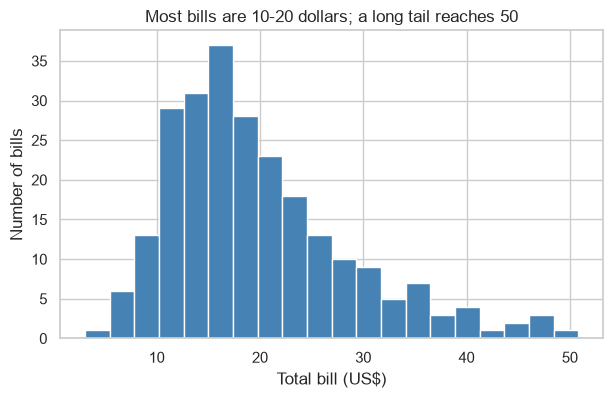

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tips["total_bill"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Most bills are 10-20 dollars; a long tail reaches 50")
ax.set_xlabel("Total bill (US$)")
ax.set_ylabel("Number of bills")
plt.show()

# The distribution is right-skewed: most bills are modest,
# and a few large bills stretch the tail to the right.

### Solution 2

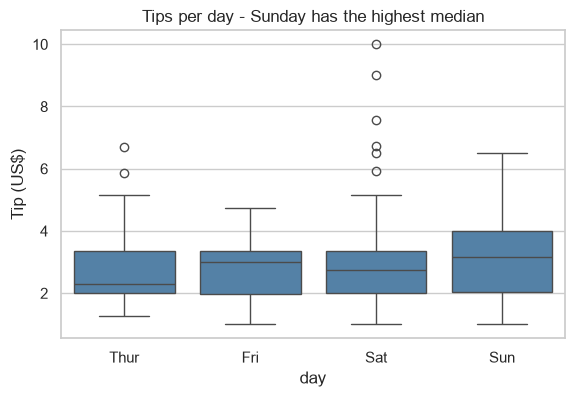

day
Thur    2.30
Fri     3.00
Sat     2.75
Sun     3.15
Name: tip, dtype: float64
Highest median tip: Sun


In [34]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.boxplot(data=tips, x="day", y="tip", color="steelblue", ax=ax)
ax.set_title("Tips per day - Sunday has the highest median")
ax.set_ylabel("Tip (US$)")
plt.show()

medians = tips.groupby("day", observed=True)["tip"].median()
print(medians.round(2))
print("Highest median tip:", medians.idxmax())

### Solution 3

Problems with the original chart (any three of these):

1. A pie chart with 4 categories — bar lengths compare better than slice angles.
2. The title "Chart" carries no message.
3. No values shown anywhere — the reader cannot read a single number.
4. Unsorted categories — no visible ranking.

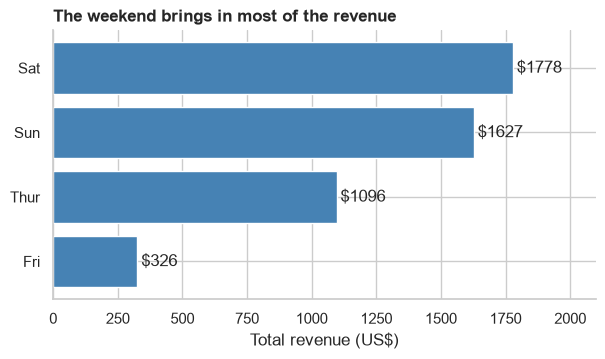

In [35]:
share = tips.groupby("day", observed=True)["total_bill"].sum().sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(share.index.astype(str), share, color="steelblue")
for i, value in enumerate(share):
    ax.text(value + 15, i, f"${value:.0f}", va="center")
ax.set_xlim(0, share.max() * 1.18)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_xlabel("Total revenue (US$)")
ax.set_title("The weekend brings in most of the revenue", loc="left", fontweight="bold")
plt.show()

### Solution 4

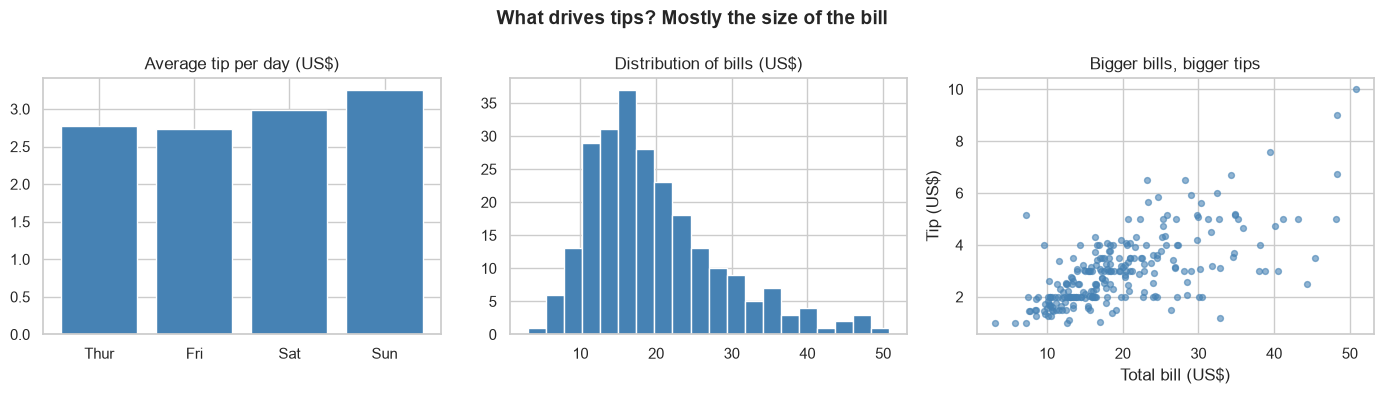

In [36]:
avg_tip = tips.groupby("day", observed=True)["tip"].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(avg_tip.index.astype(str), avg_tip, color="steelblue")
axes[0].set_title("Average tip per day (US$)")

axes[1].hist(tips["total_bill"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of bills (US$)")

axes[2].scatter(tips["total_bill"], tips["tip"], alpha=0.6, color="steelblue", s=18)
axes[2].set_title("Bigger bills, bigger tips")
axes[2].set_xlabel("Total bill (US$)")
axes[2].set_ylabel("Tip (US$)")

fig.suptitle("What drives tips? Mostly the size of the bill", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Well done. You can now choose the right chart, style it professionally, make it interactive, and assemble charts into a dashboard you can share as a single file. In the next notebooks you will use these skills on every dataset you meet.